In [21]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import urllib
import matplotlib.pyplot as plt

## Softmax
In classification problems, we're given an image and asked to predict which of several predefined objects is pictured. For example, in MNIST, we have 10 different digits, and each image contains exactly one of them. However, due to noise, imperfect networks, or bad handwriting, we can't always be completely sure of our answer. Instead, we'll want give our answer as a probability distribution. However, we know that neural networks do not inherently produce a probability distribution, and don't even have the concept of what that is, we need to add _something_ inbetween the final linear layer and the numbers we consider the result.

In english...
Start with a vector of numbers. Compute e^x for each value in the vector to produce a new vector. Finally, divide every value by the sum of all these exponentials.

Softmax has some useful properties.
1. Inputs can be anything, and individual outputs are all between 0 and 1
1. Sum of all elements of the output vector add up to 1.
1. Simple derivatives.

The first two properties make softmax good for computing the loss in neural networks that predict probability distributions.
Classifiers are such networks, and have outputs that assign each class a probability. Imagine a network that has been trained to predict if an image contains a cat, dog, or a horse. The final linear layer might produce an output like this for a given image...
```
cat: 2.223
dog: -3.395
horse: 4.574
```
We can already tell from the highest value that "horse" would be the prediction, but how confident is this result? If you apply the softmax...
```
cat: 0.086959
dog: 0.00031583
horse: 0.91273
```
Which is a bit of a surprising result, considering that the pre-softmax for cat does not seem much smaller than the pre-softmax value for horse.

Another reason we need the prediction to be in this form (between 0 and 1, all outputs sum to 1) is that our label also looks this way. Using the same cat/dog/horse example, how would we say that we're 100% sure an image is a cat, but as a probability distribution?
```
cat: 1.0
dog: 0.0
horse: 0.0
```
It's simply a distribution that's 1.0 for the labeled class, and zero everywhere else. You'll sometimes see this referred to as a one-hot vector.
Now we have both a prediction and a label we ju

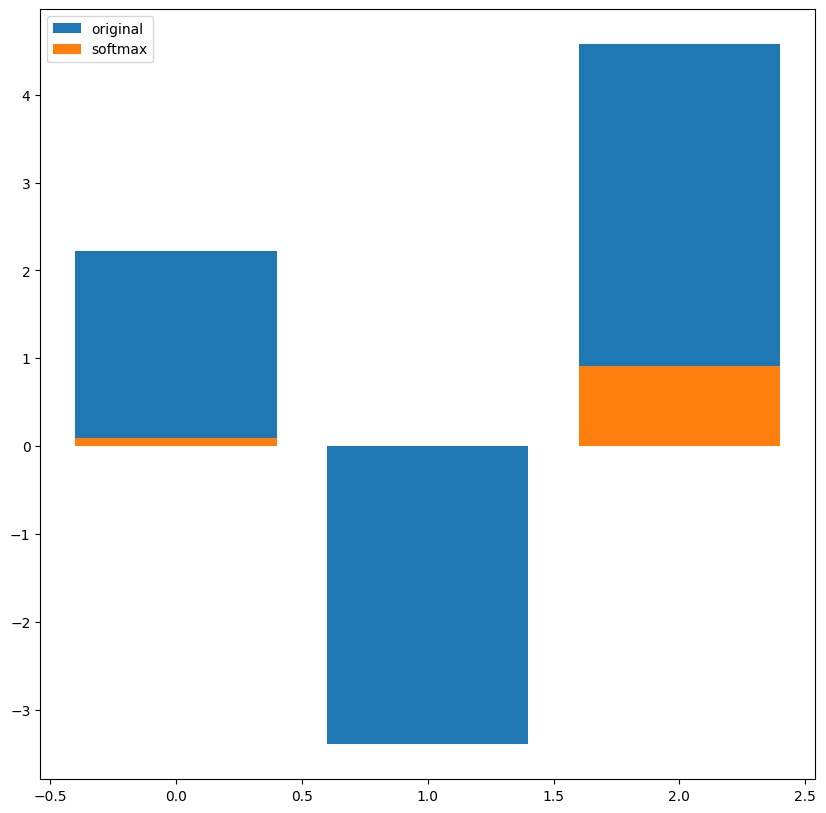

In [22]:
preds = torch.tensor([2.223, -3.395, 4.574])
probs = F.softmax(preds, dim=0)

plt.bar([0, 1, 2], preds, label='original')
plt.bar([0, 1, 2], F.softmax(preds, dim=0), label='softmax')
plt.legend()

```
cat: 0.086959
dog: 0.00031583
horse: 0.91273
```
Which is a bit of a surprising result, considering that the pre-softmax for cat does not seem much smaller than the pre-softmax value for horse.

Another reason we need the prediction to be in this form (between 0 and 1, all outputs sum to 1) is that our label also looks this way. Using the same cat/dog/horse example, how would we say that we're 100% sure an image is a cat, but as a probability distribution?
```
cat: 1.0
dog: 0.0
horse: 0.0
```
It's simply a distribution that's 1.0 for the labeled class, and zero everywhere else. You'll sometimes see this referred to as a one-hot vector.
Now we have both a prediction and a label we need a way calculate how "good" the prediction is. Since the label and the prediction both fall within the same ranges, you could imagine using the L1loss (mean of absolute value of differences) or mean-squared error to compare them, which we'll be doing in our first attempt at multi-class classification (although it turns out that a different loss function is actually much better suited to this task)

In [23]:
mseloss = nn.MSELoss()
loss = mseloss(
    probs,
    torch.tensor([1.0, 0.0, 0.0])
)
print("Loss if we incorrectly predicted horse, but the label was cat", loss.item())

loss = mseloss(
    probs,
    torch.tensor([0.0, 0.0, 1.0])
)
print("Loss if we correctly predicted horse, and the label was horse", loss.item())

Loss if we incorrectly predicted horse, but the label was cat 0.5555705428123474
Loss if we correctly predicted horse, and the label was horse 0.0050596073269844055


## Convolution
Putting the "C" in CNN, we finally get to convolutions. Although the convolution operator (and other siblings) appear in multiple contexts, it has always been a staple in image processing.

A luck would have it, there's a [3Blue1Brown video](https://www.youtube.com/watch?v=KuXjwB4LzSA) on the topic!

In [24]:
IMAGE_PATH = 'datasets/shibuya.jpg'
plt.rcParams["figure.figsize"] = (10,10)

In [25]:
urllib.request.urlretrieve('https://upload.wikimedia.org/wikipedia/commons/thumb/c/c2/2018_Shibuya_Crossing.jpg/1200px-2018_Shibuya_Crossing.jpg', IMAGE_PATH)

('datasets/shibuya.jpg', <http.client.HTTPMessage at 0x2a5ae8c7490>)

In [26]:
def draw_img(img: torch.Tensor):
    if len(img.shape) == 3:
        hwc = img.permute(1, 2, 0)
    elif len(img.shape) == 4:
        hwc = img.permute(0, 2, 3, 1)

    plt.imshow(hwc, cmap='gray')

def normalize_img(img):
    # Shift image so the smallest value is zero
    tmp = img - img.min()
    # Divide by the max so the largest value is 1
    out = tmp / tmp.max()
    return (out*255).to(torch.uint8)

In [27]:
# Load the shibuya img in channel, height, width order
img_rgb = torchvision.io.read_image(IMAGE_PATH)
# Make a lazy grayscale version by averaging the channel dimension
img_gray = img_rgb.float().mean(dim=0, keepdim=True)

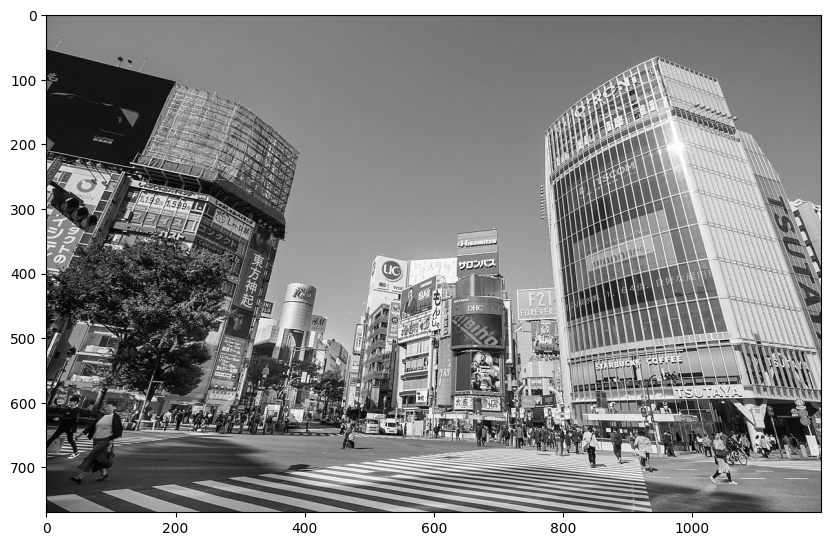

In [28]:
draw_img(img_gray)

In [29]:
sharpen = torch.tensor([
    [0, 0, -0.2, 0, 0],
    [0, -0.2, -0.5, -0.5, 0],
    [-0.2, -0.5, 5, -0.5, -0.2],
    [0, -0.2, -0.5, -0.5, 0],
    [0, 0, -0.2, 0, 0],
], dtype=torch.float32).reshape(1,1,5,5)

moving_average = torch.ones(1,1,5,5, dtype=torch.float32) / 25

vertical_edge = torch.tensor([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1],
], dtype=torch.float32).reshape(1,1,3,3)

horizontal_edge = torch.tensor([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1],
], dtype=torch.float32).reshape(1,1,3,3)

In [30]:
acc = img_gray
acc = F.conv2d(acc, horizontal_edge, stride=1, padding=2)

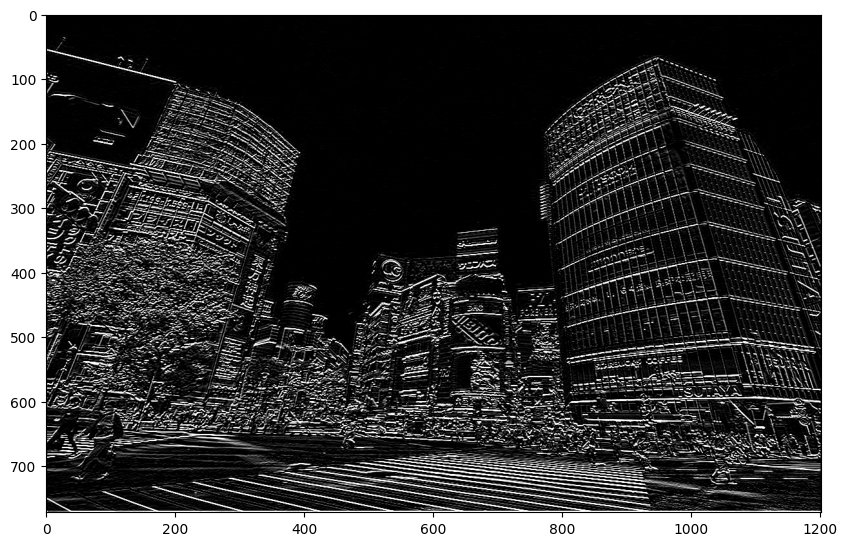

In [31]:
draw_img(acc.clamp(0, 255).byte())

## Homework
1. Please implement softmax by filling out the `mysoftmax(x)` function below. Your function will receive of a list of float values, and should return a list of floats of the same size. Compare your results    with torch's softmax on the plot.
2. Watch the [3Blue1Brown video](https://www.youtube.com/watch?v=KuXjwB4LzSA) on the topic on convolutions for next time.

In [ ]:
a = torch.randn(10)

# Softmax, written out in a for loop
def mysoftmax(x):
    exps = []
    total = 0
    for value in x:
        tmp = math.exp(value)
        exps.append(tmp)
        total += tmp
    outs = []
    for value in exps:
        outs.append(value / total)
    return outs

outs = mysoftmax(a.flatten().tolist())
    

plt.plot(a, label='original')
plt.plot(F.softmax(a, dim=0), label='torch softmax')
plt.plot(outs, 'g--', label='my softmax')
plt.legend()